# Star catalogue for F-CAMs

In preparation of the scvPIC, we need prepare a list of 300 stars for observations with PLATO F-CAMs. The main idea behind this sample is to thoroughly test and improve theory of stellar structure and evolution across the HRD. The sample needs to be prepared by the upcoming Monday, and we need your help on this front. To begin with, could you please select stars with $P \leq 10$ from your Gaia magnitude-limited catalog in LOPS2. Then, from the resulting sub-sample, could you please select the following categories using classifications as listed in Simbad:

- Blue supergiants
- Asymptotic Giant Branch (AGB) stars
- Post Asymptotic Giant Branch (post-AGB) stars
- Contact/interacting binaries, spectral types O and B
- Algol-type binaries

It would be fabulous if you could deliver the lists by the end of this week. It will suffice if these lists contain the following columns: 1) Gaia DR3 ID, 2) RA & DEC, 3) G-band magnitude

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important;}</style>"))

In [178]:
# Define paths used throughout
path = Path(os.getenv('PLATO_WORKDIR')) / 'mocka'
idir = path / 'input'
fdir = path / 'plots'

# Use seed for reproducebility
seed = 12345
rng = ut.rng(seed)

In [439]:
def fetch_gaia_info(df):
    """Fetch Gaia info for each source in data frame.
    Use NASA/IPAC Extragalactic Database (NED).
    """
    for i in range(df.shape[0]):
        di = df.reset_index(drop=True).loc[i]
        ra, dec = di.ra, di.dec
        dx = sq.gaiaQueryCone(ra, dec, radius=0.001, mag_max=14, flag_stellar=True)
        if dx.shape[0] > 1:
            dx = dx[dx.dis == 0]
        if i == 0:
            dq = dx
        else:
            dq = pd.concat((dq, dx))
            
    # Alter data frame
    dq = dq.reset_index(drop=True)
    dq = dq.drop(columns='dis')    
    return dq

## Load PLATO-CS F-CAM catalogue

In [814]:
# Load F-CAM catalogue
df = pd.read_feather(idir / 'starcat_GaiaDR3_FCAM_LOPS2.ftr')
df.gaiaDR3 = df.gaiaDR3.astype(np.int64)

In [253]:
# # Fetch bright stars
# df = df[df.Pmag <= 10].reset_index(drop=True)
# df.shape[0]

In [79]:
# save = np.arange(0, 190000, 1000)
# save[-1] = dt.shape[0]

In [185]:
# # Fetch OTYPE of Simbad to assemble catalogue
# for s in range(len(save)-1):
#     for i in tqdm(range(save[s], save[s+1]), bar_format=ut.tqdmBar()):
#         di = sq.simbadQuery(f'Gaia DR3 {dt.gaiaDR3.iloc[i]}')
#         if i == save[s]: dq = di
#         else: dq = pd.concat([dq, di])
#     dq = dq.reset_index(drop=True)
#     dq.to_feather(idir / f'starcat_GaiaDR3_FCAM_LOPS2_Pmax13_{s}.ftr')

In [807]:
# df = pd.read_feather(idir / 'starcat_GaiaDR3_FCAM_LOPS2.ftr')
dt = df[df.Gmag <= 13.5].reset_index(drop=True)
files = sorted(glob.glob(f'{idir}/starcat_GaiaDR3_FCAM_LOPS2_Pmax13_**.ftr'))
dq = pd.read_feather(files[0])
for f in files[1:]:
    di = pd.read_feather(f)
    dq = pd.concat([dq, di])
dq = dq.reset_index(drop=True)

<IPython.core.display.Javascript object>


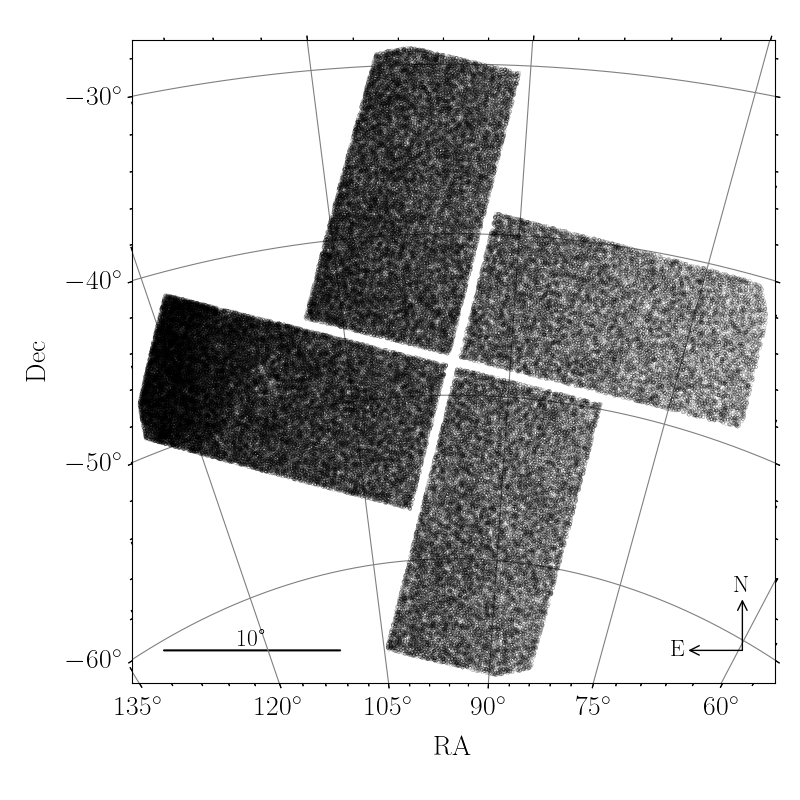

In [808]:
# Correct data frame
dt = dt.iloc[0:dq.shape[0]-1]
dq = dq.reset_index(drop=True)
dt['otype'] = dq.otype
dt.insert(0, 'source', dq.source)
dt = dt.drop(columns='ncams')

fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dt.ra, decStars=dt.dec,
                          showGroups=False, showFcamFOV=False, 
                          fovSize=20, fs=20, ms=5, figsize=(8,8))

In [288]:
# Save catalogue
# dt.to_feather(idir / 'starcat_GaiaDR3_FCAM_LOPS2_Pmax10.ftr')

---

The following OTYPE names are used:

- Blue supergiants: `BlueSG`
- Asymptotic Giant Branch (AGB) stars: `AGB*`
- Post Asymptotic Giant Branch (post-AGB) stars: `post-AGB*`
- Contact/interacting binaries, spectral types O and B: ``
- Algol-type binaries: `Al*`

Reference: `https://simbad.cds.unistra.fr/Pages/guide/otypes.htx`

In [815]:
dt = pd.read_feather(idir / 'starcat_GaiaDR3_FCAM_LOPS2_Pmax10.ftr')
dt.gaiaDR3 = dt.gaiaDR3.astype(np.int64)

In [816]:
dt_BSG  = dt[dt.otype == 'BlueSG']
dt_AGB  = dt[dt.otype == 'AGB*']
dt_pAGB = dt[dt.otype == 'post-AGB*']
dt_BSG.shape[0], dt_AGB.shape[0], dt_pAGB.shape[0]

(1, 0, 1)

In [817]:
dx = dt_BSG
do = pd.DataFrame()
do['source'] = dx.source
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = dx.otype
dt0 = do.reset_index(drop=True)

In [818]:
dx = dt_pAGB
do = pd.DataFrame()
do['source'] = dx.source
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = dx.otype
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])

### EBs from catalogue

In [819]:
dt_binary = dt[(dt.otype == '**')]
dt_binary.shape[0]

152

In [820]:
dx = dt_binary
do = pd.DataFrame()
do['source'] = dx.source
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = dx.otype
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])

In [821]:
dt_SBA = dt[(dt.otype == 'SB*') & (dt.spec == 'A')]
dt_SBA.shape[0]

65

In [822]:
dx = dt_SBA
do = pd.DataFrame()
do['source'] = dx.source
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = dx.otype
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])

In [823]:
dt_SBB = dt[(dt.otype == 'SB*') & (dt.spec == 'B')]
dt_SBB.shape[0]

10

In [824]:
dx = dt_SBB
do = pd.DataFrame()
do['source'] = dx.source
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = dx.otype
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])

In [825]:
dt0

,source,gaiaDR3,ra,dec,Gmag,Teff,Lum,otype
0,* J Pup,5518235833732209536,118.325618,-48.102908,4.174098,NaN,NaN,BlueSG
0,V* ST Pup,5577329081864722176,102.235054,-37.275911,10.029096,5184.0,427.099701,post-AGB*
0,* P Pup,5530670107652889344,117.309528,-46.373170,4.034592,19981.0,NaN,**
1,HD 62644,5531762678610961664,115.737400,-45.175578,4.834570,5350.0,4.885921,**
2,CD-35 2947,5581347350187610240,97.804539,-35.258814,5.601349,5157.0,271.825256,**
...,...,...,...,...,...,...,...,...
5,HD 45796,5477233430220256384,96.232426,-63.828088,6.244213,12666.0,238.240341,SB*
6,HD 48246,5483141930829634304,99.660234,-60.182983,7.029068,12202.0,387.615662,SB*
7,HD 59869,5507654374342350464,112.438926,-46.689427,7.391816,11381.0,66.464470,SB*
8,HD 48559,5483451924389290752,100.091105,-59.123157,7.753479,15023.0,558.358704,SB*


### Cross-match with EBs (IJspeert+2024)

In [826]:
# Download file from FTP
ut.downloadFromFTP('table_OBAF_EB_catalogue.csv')

In [827]:
# Load catalogue
ebdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles'
db = pd.read_csv(ebdir / 'table_OBAF_EB_catalogue.csv')

In [828]:
# Cross-match with Luc's catalogue
dt.gaiaDR3 = dt.gaiaDR3.astype(float)
db0 = db[db['GAIA_DR3'].isin(dt['gaiaDR3'])].sort_values(by=['GAIA_DR3']).reset_index(drop=True)
dt0_EB = dt[dt['gaiaDR3'].isin(db['GAIA_DR3'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)
dt_EB = dt0_EB
dt_EB.shape[0]

92

In [829]:
dx = dt_EB
do = pd.DataFrame()
do['source'] = dx.source
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = dx.otype
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])

In [830]:
dt0

,source,gaiaDR3,ra,dec,Gmag,Teff,Lum,otype
0,* J Pup,5.518236e+18,118.325618,-48.102908,4.174098,NaN,NaN,BlueSG
0,V* ST Pup,5.577329e+18,102.235054,-37.275911,10.029096,5184.0,427.099701,post-AGB*
0,* P Pup,5.530670e+18,117.309528,-46.373170,4.034592,19981.0,NaN,**
1,HD 62644,5.531763e+18,115.737400,-45.175578,4.834570,5350.0,4.885921,**
2,CD-35 2947,5.581347e+18,97.804539,-35.258814,5.601349,5157.0,271.825256,**
...,...,...,...,...,...,...,...,...
87,HD 50124,5.576146e+18,102.494417,-39.079092,8.934177,6784.0,12.580809,SB*
88,HD 48068,5.577114e+18,99.933021,-37.720238,9.238763,11807.0,445.658447,Star
89,HD 49030,5.577598e+18,101.188746,-36.657355,8.475611,7207.0,13.854474,Star
90,HD 50783,5.578126e+18,103.252632,-36.680575,9.096880,6388.0,2.857397,Star


### Other catalogues

In [831]:
sdir = Path(os.getenv('PLATO_WORKDIR')) / 'scvPIC'

In [832]:
df_pMS = pd.read_csv(sdir / 'PLATO-Bright-PreMS-scvPIC.csv')
dt_pMS = df[df['gaiaDR3'].isin(df_pMS['Gaia DR3 ID'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)
print(df_pMS.shape[0], dt_pMS.shape[0])

dx = dt_pMS
do = pd.DataFrame()
do['source'] = np.nan
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = 'pre-MS'
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])
dt0

53 24


,source,gaiaDR3,ra,dec,Gmag,Teff,Lum,otype
0,* J Pup,5.518236e+18,118.325618,-48.102908,4.174098,NaN,NaN,BlueSG
0,V* ST Pup,5.577329e+18,102.235054,-37.275911,10.029096,5184.0,427.099701,post-AGB*
0,* P Pup,5.530670e+18,117.309528,-46.373170,4.034592,19981.0,NaN,**
1,HD 62644,5.531763e+18,115.737400,-45.175578,4.834570,5350.0,4.885921,**
2,CD-35 2947,5.581347e+18,97.804539,-35.258814,5.601349,5157.0,271.825256,**
...,...,...,...,...,...,...,...,...
19,NaN,5.519226e+18,122.841116,-47.191116,10.284913,NaN,NaN,pre-MS
20,NaN,5.519288e+18,122.375441,-46.965500,12.559175,5142.0,1.762242,pre-MS
21,NaN,5.520603e+18,120.726613,-45.094688,13.193451,4793.0,0.906097,pre-MS
22,NaN,5.530441e+18,115.804880,-47.769108,13.296932,5139.0,1.510316,pre-MS


In [833]:
# Missing WDs from catalogue
dex = [0]
dx = df_pMS
gaia = np.array([dx['Gaia DR3 ID'].iloc[i] for i in dex]).astype(np.int64) 
ra   = np.array([dx.iloc[i].RA for i in dex]) 
dec  = np.array([dx.iloc[i].DE for i in dex])
dx = pd.DataFrame({'gaiaDR3': gaia, 'ra': ra, 'dec': dec})
dx_pMS = fetch_gaia_info(dx)

dx = dx_pMS
do = pd.DataFrame()
do['source'] = np.nan
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = 'pre-MS'
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])
dt0

,source,gaiaDR3,ra,dec,Gmag,Teff,Lum,otype
0,* J Pup,5.518236e+18,118.325618,-48.102908,4.174098,NaN,NaN,BlueSG
0,V* ST Pup,5.577329e+18,102.235054,-37.275911,10.029096,5184.0,427.099701,post-AGB*
0,* P Pup,5.530670e+18,117.309528,-46.373170,4.034592,19981.0,NaN,**
1,HD 62644,5.531763e+18,115.737400,-45.175578,4.834570,5350.0,4.885921,**
2,CD-35 2947,5.581347e+18,97.804539,-35.258814,5.601349,5157.0,271.825256,**
...,...,...,...,...,...,...,...,...
20,NaN,5.519288e+18,122.375441,-46.965500,12.559175,5142.0,1.762242,pre-MS
21,NaN,5.520603e+18,120.726613,-45.094688,13.193451,4793.0,0.906097,pre-MS
22,NaN,5.530441e+18,115.804880,-47.769108,13.296932,5139.0,1.510316,pre-MS
23,NaN,5.532141e+18,117.053487,-44.400512,12.846434,NaN,NaN,pre-MS


---

In [834]:
df_sd  = pd.read_csv(sdir / 'sd_x_LOPS2.csv')
dt_sd = df[df['gaiaDR3'].isin(df_sd['GaiaEDR3'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)
print(df_sd.shape[0], dt_sd.shape[0])

dx = dt_sd
do = pd.DataFrame()
do['source'] = np.nan
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = 'sd'
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])

65 2


In [835]:
# Missing WDs from catalogue
dex = [0, 2, 9, 17, 21, 24, 27, 31, 34, 40, 41, 42, 43, 48, 51, 59]
dx = df_sd
gaia = np.array([dx['GaiaEDR3'].iloc[i] for i in dex]).astype(np.int64) 
ra   = np.array([dx['RA_ICRS'].iloc[i] for i in dex]) 
dec  = np.array([dx['DE_ICRS'].iloc[i] for i in dex])
dx = pd.DataFrame({'gaiaDR3': gaia, 'ra': ra, 'dec': dec})
dx_sd = fetch_gaia_info(dx)
dx = dx_sd
do = pd.DataFrame()
do['source'] = np.nan
do['gaiaDR3'] = dx.gaiaDR3
do['ra'] = dx.ra
do['dec'] = dx.dec
do['Gmag'] = dx.Gmag
do['Teff'] = dx.Teff
do['Lum'] = dx.L
do['otype'] = 'sd'
do = do.reset_index(drop=True)
dt0 = pd.concat([dt0, do])
dt0

,source,gaiaDR3,ra,dec,Gmag,Teff,Lum,otype
0,* J Pup,5.518236e+18,118.325618,-48.102908,4.174098,NaN,NaN,BlueSG
0,V* ST Pup,5.577329e+18,102.235054,-37.275911,10.029096,5184.0,427.099701,post-AGB*
0,* P Pup,5.530670e+18,117.309528,-46.373170,4.034592,19981.0,NaN,**
1,HD 62644,5.531763e+18,115.737400,-45.175578,4.834570,5350.0,4.885921,**
2,CD-35 2947,5.581347e+18,97.804539,-35.258814,5.601349,5157.0,271.825256,**
...,...,...,...,...,...,...,...,...
11,NaN,4.765261e+18,87.188845,-58.290049,13.041444,NaN,NaN,sd
12,NaN,4.793128e+18,85.837809,-51.437101,13.062028,36919.0,NaN,sd
13,NaN,5.572009e+18,93.868357,-41.335344,13.202349,NaN,NaN,sd
14,NaN,2.896588e+18,95.248625,-29.683141,13.261356,NaN,NaN,sd


In [836]:
df_WD  = pd.read_csv(sdir / 'wd_x_LOPS2.csv')
dt_WD = df[df['gaiaDR3'].isin(df_WD['GaiaEDR3'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)

# Missing WDs from catalogue
dex = [1, 2, 4, 9, 12]
gaia_WD = np.array([df_WD.iloc[i].GaiaEDR3 for i in dex]).astype(np.int64) 
ra_WD = np.array([df_WD.iloc[i].RA_ICRS for i in dex]) 
dec_WD = np.array([df_WD.iloc[i].DE_ICRS for i in dex])
dx = pd.DataFrame({'gaiaDR3': gaia_WD, 
                   'ra': ra_WD, 
                   'dec': dec_WD})
dx = fetch_gaia_info(dx)

# Generate WD catalogue
dt_WD = pd.DataFrame()
dt_WD['gaiaDR3'] = dx.gaiaDR3
dt_WD['ra'] = dx.ra
dt_WD['dec'] = dx.dec
dt_WD['Gmag'] = dx.Gmag
dt_WD['Teff'] = dx.Teff
dt_WD['Lum'] = dx.L
dt_WD['otype'] = 'WD'

### Plot star in sky

In [635]:
# df_pMS[df_pMS.RA < 90]

<IPython.core.display.Javascript object>


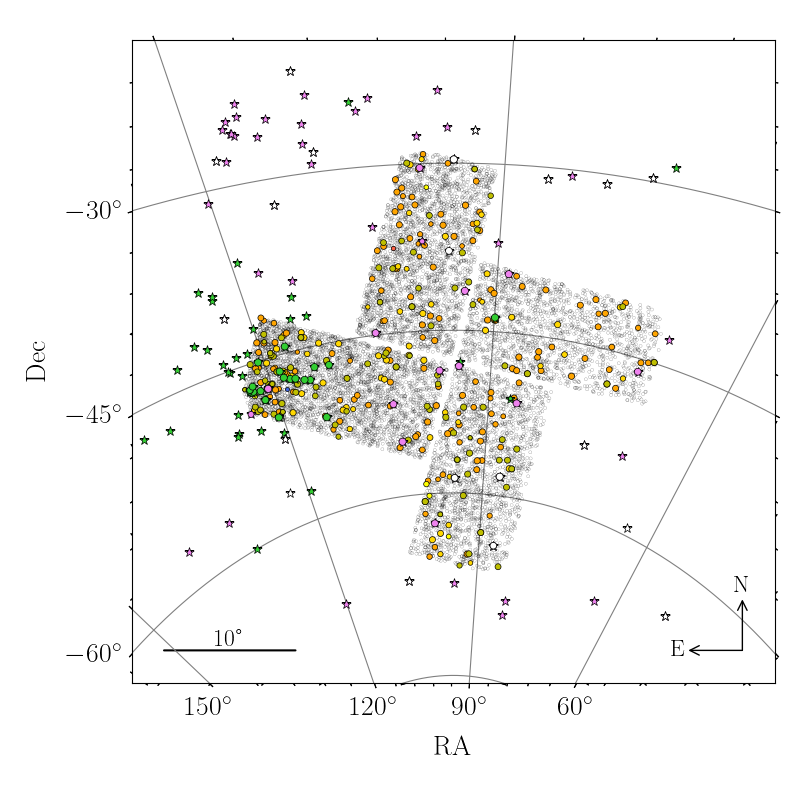

In [845]:
# Show pointign field
zorder = 10
s = 2
dx = dt.iloc[::1]
fov = 30
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dx.ra, decStars=dx.dec,
                          showGroups=False, showFcamFOV=False, 
                          fovSize=fov, fs=20, ms=5, aa=1, figsize=(8,8))

ax.scatter(dt_binary.ra, dt_binary.dec, s=s*dt_binary.Gmag, marker='o', edgecolor='k', facecolor='orange',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_SBA.ra, dt_SBA.dec, s=s*dt_SBA.Gmag, marker='o', edgecolor='k', facecolor='gold',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_SBB.ra, dt_SBB.dec, s=s*dt_SBB.Gmag, marker='o', edgecolor='k', facecolor='yellow',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_EB.ra, dt_EB.dec, s=s*dt_EB.Gmag, marker='o', edgecolor='k', facecolor='y',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(df_pMS.RA, df_pMS.DE, s=50, marker='*', edgecolor='k', facecolor='limegreen', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
dx = dt0[dt0.otype == 'pre-MS']
ax.scatter(dx.ra, dx.dec, s=s*dx.Gmag, marker='o', edgecolor='k', facecolor='limegreen', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(df_sd.RA_ICRS, df_sd.DE_ICRS, s=50, marker='*', edgecolor='k', facecolor='violet', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
dx = dt0[dt0.otype == 'sd']
ax.scatter(dx.ra, dx.dec, s=s*dx.Gmag, marker='o', edgecolor='k', facecolor='violet', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
# dex = [0, 2, 9, 17, 21, 24, 27, 31, 34, 40, 41, 42, 43, 48, 51, 59]
# dex = 0
# ax.scatter(df_sd.RA_ICRS.iloc[dex], df_sd.DE_ICRS.iloc[dex], s=100, marker='s', edgecolor='k', facecolor='r', 
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

ax.scatter(df_WD.RA_ICRS, df_WD.DE_ICRS, s=50, marker='*', edgecolor='k', facecolor='w', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_WD.ra, dt_WD.dec, s=s*dt_WD.Gmag, marker='o', edgecolor='k', facecolor='w', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

dx = dt0[dt0.otype == 'BlueSG']
ax.scatter(dx.ra, dx.dec, s=s*dx.Gmag, marker='o', edgecolor='k', facecolor='royalblue', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

# ax.scatter(dt_AGB.ra, dt_AGB.dec, s=dt_AGB.Gmag, marker='o', edgecolor='w', facecolor='deeppink', 
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

dx = dt0[dt0.otype == 'post-AGB*']
ax.scatter(dx.ra, dx.dec, s=dx.Gmag, marker='o', edgecolor='k', facecolor='tomato', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

fig.savefig(fdir / f'starcat_GaiaDR3_FCAM_LOPS2_FOV{fov}deg.png', bbox_inches='tight', dpi=300);

<IPython.core.display.Javascript object>


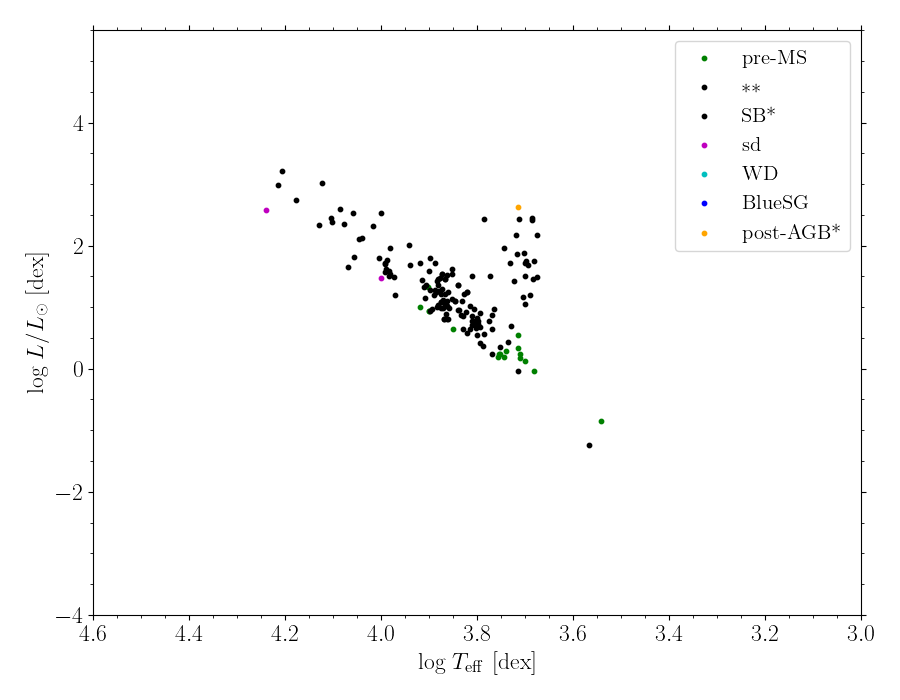

In [872]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))
# ax.plot(dt0.Teff, dt0.Lum, 'o')
colors = ['g', 'k', 'k', 'm', 'c', 'b', 'orange']
otypes = ['pre-MS', '**', 'SB*', 'sd', 'WD', 'BlueSG', 'post-AGB*']
for color, otype in zip(colors, otypes):
    dx = dt0[dt0.otype == otype]
    ax.scatter(np.log10(dx.Teff), np.log10(dx.Lum), c=color, s=10, cmap="rainbow", label=otype)
ax.set_xlabel(r'log $T_{\rm eff}$ [dex]')
ax.set_ylabel(r'log $L/L_{\odot}$ [dex]')
ax.invert_xaxis()
ax.set_xlim(4.6, 3.0)
ax.set_ylim(-4.0, 5.5)
ax.legend()
plt.tight_layout()
fig.savefig(fdir / 'HRD_FCAM_LOPS2.png', bbox_inches='tight', dpi=300);

In [846]:
dt_save = dt0
dt_save = dt_save.drop(columns=['source'])
dt_save

,gaiaDR3,ra,dec,Gmag,Teff,Lum,otype
0,5.518236e+18,118.325618,-48.102908,4.174098,NaN,NaN,BlueSG
0,5.577329e+18,102.235054,-37.275911,10.029096,5184.0,427.099701,post-AGB*
0,5.530670e+18,117.309528,-46.373170,4.034592,19981.0,NaN,**
1,5.531763e+18,115.737400,-45.175578,4.834570,5350.0,4.885921,**
2,5.581347e+18,97.804539,-35.258814,5.601349,5157.0,271.825256,**
...,...,...,...,...,...,...,...
11,4.765261e+18,87.188845,-58.290049,13.041444,NaN,NaN,sd
12,4.793128e+18,85.837809,-51.437101,13.062028,36919.0,NaN,sd
13,5.572009e+18,93.868357,-41.335344,13.202349,NaN,NaN,sd
14,2.896588e+18,95.248625,-29.683141,13.261356,NaN,NaN,sd


In [848]:
dt_save = dt_save.reset_index(drop=True)
dt_save.to_csv(idir / 'scvPIC_FCAM_G10mag.txt', index=False)